# Autoencoder for Image Denoising

### Objective:
Build a deep learning model that can remove noise from images using an autoencoder on MNIST

### Importing Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

### Load Dataset


In [3]:
(x_train,_),(x_test,_)=mnist.load_data()
print("Training Images:",x_train.shape)
print("Testing Images:",x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


### Data Preprocessing

In [4]:
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.

x_train=np.reshape(x_train,(len(x_train),28,28,1))
x_test=np.reshape(x_test,(len(x_test),28,28,1))

### Adding Gaussian Noise

In [5]:
noise_factor=0.5
x_train_noisy=x_train+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_train.shape)
x_test_noisy=x_test+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_test.shape)
x_train_noisy=np.clip(x_train_noisy,0.,1.)
x_test_noisy=np.clip(x_test_noisy,0.,1.)

### Visualize Original and Noisy Images

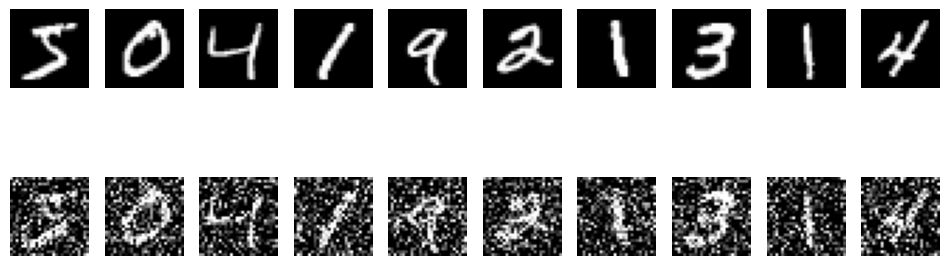

In [6]:
plt.figure(figsize=(12,4))
for i in range(10):
  ax=plt.subplot(2,10,i+1)
  plt.imshow(x_train[i].reshape(28,28),cmap='gray')
  plt.axis('off')

  ax=plt.subplot(2,10,i+11)
  plt.imshow(x_train_noisy[i].reshape(28,28),cmap='gray')
  plt.axis('off')
plt.show()

### Build the Convolutional Autoencoder

In [7]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

### Compiling the Model

In [8]:
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [9]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 196s 412ms/step - loss: 0.1608 - val_loss: 0.1151
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 184s 392ms/step - loss: 0.1112 - val_loss: 0.1061
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 187s 399ms/step - loss: 0.1054 - val_loss: 0.1028
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 184s 391ms/step - loss: 0.1024 - val_loss: 0.1015
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 215s 420ms/step - loss: 0.1007 - val_loss: 0.0991
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 434ms/step - loss: 0.0993 - val_loss: 0.0979
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 427ms/step - loss: 0.0982 - val_loss: 0.0970
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 188s 401ms/step - loss: 0.0975 - val_loss: 0.0966
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 183s 389ms/step - loss: 0.0968 - val_loss: 0.0959
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 185s 394ms/step - loss: 0.0963 - val_loss: 0.0956


### Plot Training and Validation Loss

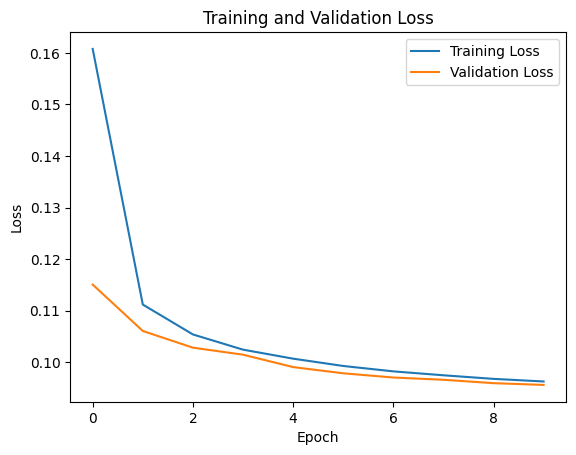

In [10]:
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

### Generate Denoised Images

In [11]:
decoded_imgs=autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step


### Compare the Results

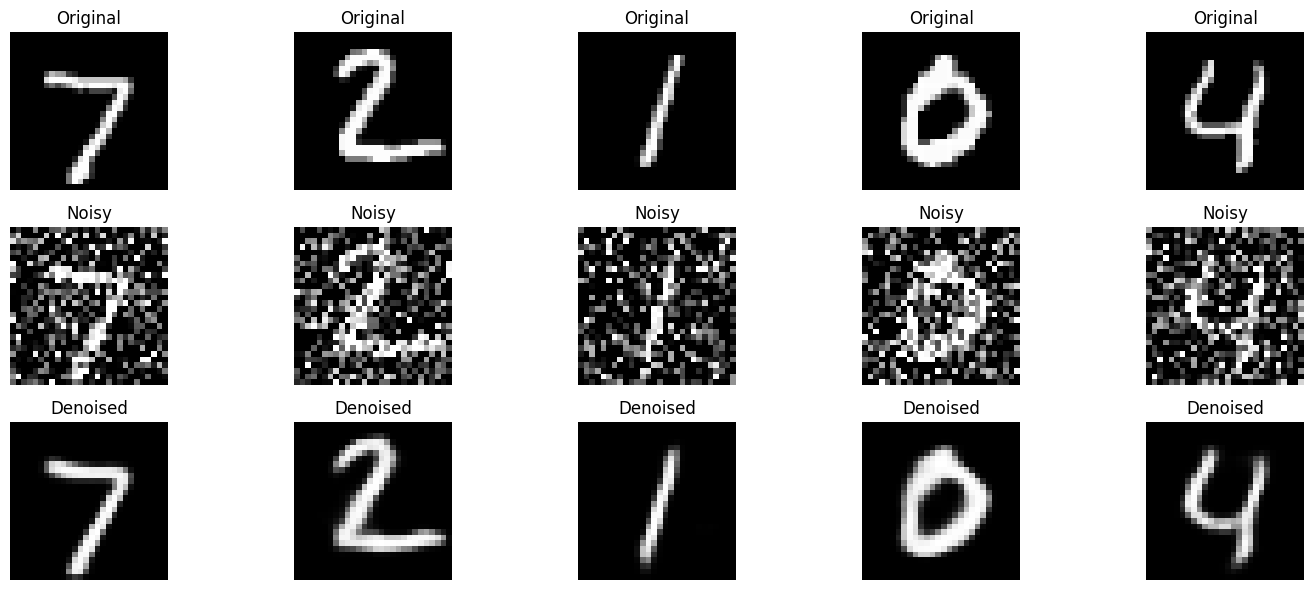

In [12]:
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  ax=plt.subplot(3,n,i+1)
  plt.imshow(x_test[i].reshape(28,28),cmap='gray')
  plt.title("Original")
  plt.axis('off')

  ax=plt.subplot(3,n,i+n+1)
  plt.imshow(x_test_noisy[i].reshape(28,28),cmap='gray')
  plt.title("Noisy")
  plt.axis('off')

  ax=plt.subplot(3,n,i+2*n+1)
  plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
  plt.title("Denoised")
  plt.axis('off')
plt.tight_layout()
plt.show()

# Conclusion

A Convolutional Autoencoder was successfully implemented for image denoising using the MNIST dataset. The model reconstructed cleaner images from noisy inputs and showed good performance through decreasing loss values. The additional experiment with a lower noise factor demonstrated that less noise results in better image reconstruction.